# 02 — Feature engineering walkthrough

Build the engineered feature frame from raw transactions, inspect the per-feature distributions by class, and verify the zero-leakage guarantee. The output of this notebook is what `src.models.train` consumes.

In [1]:
# ---------------------------------------------------------------------
# Feature-engineering exploration notebook. Imports the loader and the
# canonical feature pipeline (``build_engineered_frame``) so this
# notebook visualizes the *same* feature implementation that training
# uses — not a re-implementation that could drift.
#
# Visualization stack is matplotlib + seaborn for static charts. The
# theme matches the EDA notebook so visual continuity across notebooks
# is preserved.
# ---------------------------------------------------------------------
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.data.loader import LABEL_COLUMN, DataLoader
from src.features.pipelines import build_engineered_frame

sns.set_theme(style='whitegrid', palette='deep')
pd.set_option('display.float_format', lambda v: f'{v:,.4f}')

In [2]:
# ---------------------------------------------------------------------
# Sub-sample for the feature visualization. We use a 200k-row stratified
# sample (preserves the positive rate) rather than the full 5M frame
# because the graph-feature step is O(n_edges) and would otherwise
# dominate this notebook's wall time without changing what the
# distributions look like.
#
# The loader's ``load_sample`` enforces the same dtype/schema validation
# as a full load, so the sample is a faithful miniature of the full
# population — not a debugging shortcut.
# ---------------------------------------------------------------------
loader = DataLoader()
frame = loader.load_sample(n=200_000, random_state=42)
print(f'Sample size: {len(frame):,}')

# Sanity check that the stratified sampler preserved the class balance.
# A drift here would indicate the sampler is broken and every downstream
# feature distribution would be biased — failing fast catches that.
print(f'Positive rate preserved by stratified sampler: {frame[LABEL_COLUMN].mean():.6f}')

Sample size: 200,000
Positive rate preserved by stratified sampler: 0.001020


## 1. Build the engineered frame

The orchestrator calls each feature builder in the correct order. On 200k rows this typically completes in 20–40 seconds; the full 5M-row dataset takes ~15 minutes.

In [3]:
# ---------------------------------------------------------------------
# Materialize the engineered feature frame. ``build_engineered_frame``
# is the canonical implementation used by training, so any signal we
# inspect here is a signal the model actually sees.
#
# The output ``bundle`` carries:
#   - frame: the joined feature frame (rows × original + engineered cols)
#   - numerical_columns / categorical_columns: the explicit lists
#     consumed by the sklearn Pipeline's ColumnTransformer.
# Reporting the column counts gives a fast sanity check that all three
# feature families (entity, velocity, graph) materialized correctly.
# ---------------------------------------------------------------------
bundle = build_engineered_frame(frame)
print(f'Engineered columns: {len(bundle.numerical_columns) + len(bundle.categorical_columns)}')
print(f'  Numerical: {len(bundle.numerical_columns)}')
print(f'  Categorical: {len(bundle.categorical_columns)}')

# A preview of the first 10 numerical features lets a reviewer skim the
# naming convention (``src_24h_amount_mean`` etc.) without scrolling
# through 70+ feature names.
print('\nSample numerical features:')
print(bundle.numerical_columns[:10])

Engineered columns: 78
  Numerical: 75
  Categorical: 3

Sample numerical features:
('Amount Paid', 'Amount Received', 'src_1h_txn_count', 'src_1h_amount_sum', 'src_1h_amount_mean', 'src_1h_amount_std', 'src_1h_amount_max', 'src_1h_sub_threshold_count', 'src_1h_round_amount_count', 'src_1h_sub_threshold_share')


## 2. Distributional comparison: by class

For features that should carry signal, the illicit-class distribution should visibly differ from the licit-class distribution.

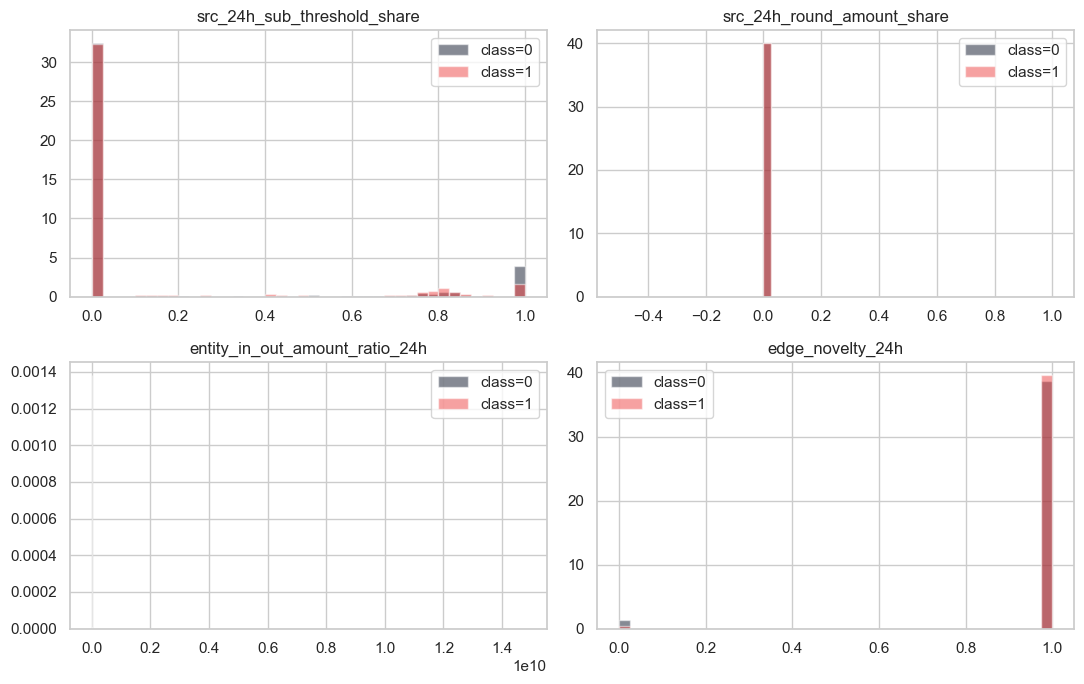

In [4]:
# ---------------------------------------------------------------------
# Class-conditional histograms of four hand-picked features that are
# domain-meaningful for AML detection:
#
#   - src_24h_sub_threshold_share — share of recent transactions just
#     below the $10k CTR reporting threshold (structuring signal)
#   - src_24h_round_amount_share — share of round-amount transactions
#     (layering signal)
#   - entity_in_out_amount_ratio_24h — inbound/outbound flow ratio
#     (mule / pass-through entity signal)
#   - edge_novelty_24h — whether this entity pair has transacted before
#     in the recent window (one-shot transfer signal)
#
# Plotting each class-1 (illicit) distribution overlaid on class-0
# (licit) at ``density=True`` (not raw count) makes shape comparison
# possible despite the ~980:1 imbalance — raw counts would crush the
# illicit histogram into invisibility.
# ---------------------------------------------------------------------
signal_features = [
    'src_24h_sub_threshold_share',
    'src_24h_round_amount_share',
    'entity_in_out_amount_ratio_24h',
    'edge_novelty_24h',
]
# Filter to features that actually exist on the engineered frame. If a
# feature was renamed in src.features the missing one drops gracefully
# rather than raising — keeps the notebook robust to schema evolution.
available = [f for f in signal_features if f in bundle.frame.columns]

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, feature in zip(axes.ravel(), available):
    for label, colour in [(0, '#0f172a'), (1, '#ef4444')]:
        # .dropna() per class because some features have NaN on first
        # transaction per entity (no rolling history); plotting NaN
        # would silently skew the density.
        values = bundle.frame.loc[bundle.frame[LABEL_COLUMN] == label, feature].dropna()
        if len(values) > 0:
            ax.hist(values, bins=40, alpha=0.5, color=colour, label=f'class={label}', density=True)
    ax.set_title(feature)
    ax.legend()
plt.tight_layout()
plt.show()

## 3. Zero-leakage verification

All rolling features are computed with `closed='left'`. The first transaction for any entity should have NaN aggregates because there is no prior history. Verify with a spot check.

In [5]:
# ---------------------------------------------------------------------
# Sanity-check the rolling-feature implementation: the first transaction
# per entity has no historical window, so count-type features must be
# filled with 0 (no transactions in the window) while mean/std/max are
# legitimately NaN (no values to aggregate).
#
# This check exists because a bug in the engineering layer that
# treated counts as NaN (instead of 0) would silently produce a model
# that fails on cold-start entities — exactly the operational scenario
# AML systems encounter daily as new customers onboard.
# ---------------------------------------------------------------------
spot_features = [c for c in bundle.numerical_columns if c.startswith('src_24h_')]

# groupby('Account').head(1) selects the first chronological row per
# source entity. The dataset is loader-sorted so head(1) is the entity's
# debut transaction; on an unsorted frame this would be a meaningless
# arbitrary row, so this notebook trusts the loader's sort guarantee.
first_per_entity = bundle.frame.groupby('Account').head(1)[spot_features]
print('NaN share on first transaction per entity (count features):')
for col in spot_features[:6]:
    print(f'  {col}: {first_per_entity[col].isna().mean():.4f}')

# The expectation is roughly zero for the count features and non-zero
# for the moment features (mean/std/max). The follow-up sentence makes
# this expected behavior visible to a reader who would otherwise wonder
# whether the count NaN-share of 0 is good or bad.
print('\n(Count features are filled with 0 by the engineering layer; mean/std/max remain NaN as expected.)')

NaN share on first transaction per entity (count features):
  src_24h_txn_count: 0.0000
  src_24h_amount_sum: 0.0000
  src_24h_amount_mean: 0.9294
  src_24h_amount_std: 0.9927
  src_24h_amount_max: 0.9294
  src_24h_sub_threshold_count: 0.0000

(Count features are filled with 0 by the engineering layer; mean/std/max remain NaN as expected.)


## 4. Feature correlation

High intra-family correlation is expected (1h is correlated with 24h windows of the same statistic). The model handles correlated features via regularisation; we surface the correlation matrix as a visual sanity check.

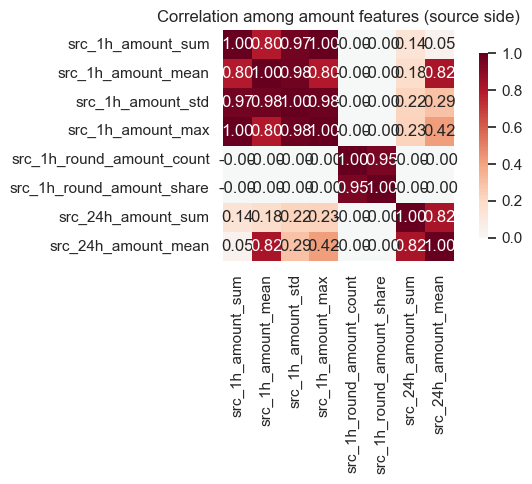

In [6]:
# ---------------------------------------------------------------------
# Inter-feature correlation among the source-side amount features. High
# correlation between two engineered features means they carry
# overlapping information — the model can drop one with negligible
# performance impact, simplifying the feature pipeline.
#
# Restricting the heatmap to 8 features keeps it readable. A 70-feature
# heatmap is visually unparsable and the meaningful redundancies are
# typically within feature families (the windowed amount features)
# anyway.
# ---------------------------------------------------------------------
subset = [c for c in bundle.numerical_columns if 'src_' in c and 'amount' in c][:8]
if len(subset) >= 2:
    corr = bundle.frame[subset].corr()
    plt.figure(figsize=(7, 5))
    # RdBu_r diverging colormap centered at 0 makes positive vs negative
    # correlation visually distinct. ``annot=True, fmt='.2f'`` prints the
    # coefficient in each cell so the static notebook is readable on
    # GitHub without zooming in on the colors.
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True, cbar_kws={'shrink': 0.8})
    plt.title('Correlation among amount features (source side)')
    plt.tight_layout()
    plt.show()

## 6. t-SNE projection of the engineered feature space

A 2D projection of the 70+ engineered features answers a question every modeling notebook should answer up front: **do the engineered features actually separate the two classes in some learnable manifold?**

If illicit and licit transactions occupy overlapping regions in the t-SNE embedding, the feature engineering layer has not produced discriminatory representations and no classifier on these features will perform well. If the two classes form distinguishable clusters or sub-regions, the downstream supervised model has signal to learn from.

t-SNE is O(n²) so we project a 5,000-row stratified sample, which is sufficient for a visual sanity check without spending minutes on dimensionality reduction.

/var/folders/s0/6b4cp_651_j2ln5zntt0pfxh0000gn/T/ipykernel_84900/92091588.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), 2500), random_state=42))


Sample composition: 2,704 rows, 204 positives (7.5444%)


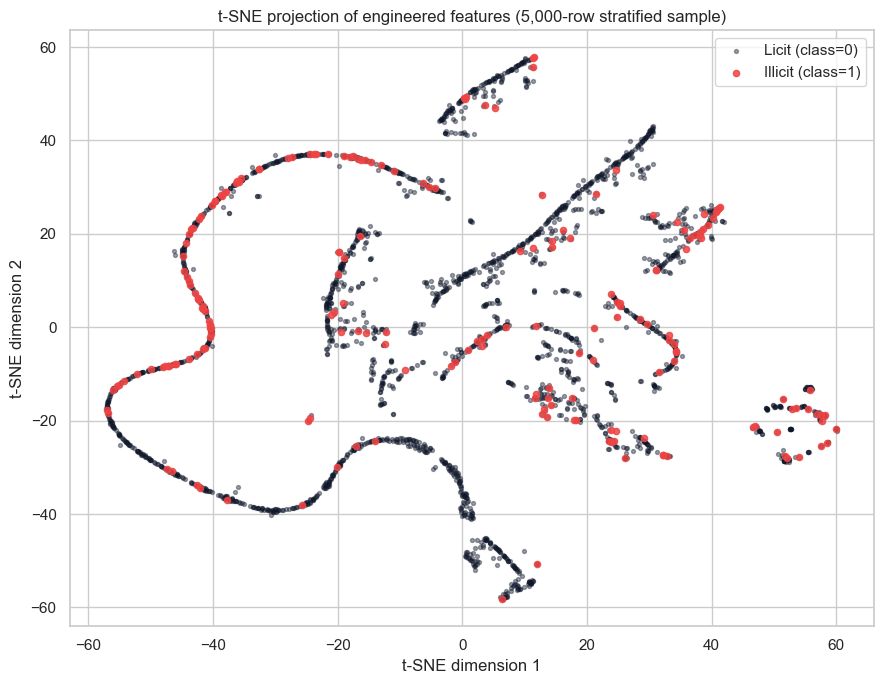

In [7]:
# ---------------------------------------------------------------------
# 2D t-SNE projection of the engineered feature space, colored by
# laundering label. The goal is a qualitative answer to "do the
# engineered features carry class-separating signal" — a question
# whose answer downstream classifiers depend on.
#
# Implementation notes:
#   - Stratified sample of 5,000 rows preserves the ~1:1000 positive
#     rate. Without stratification an unweighted sample would contain
#     ~5 positive points, which is too sparse to see in a scatter plot.
#   - perplexity=30 is the canonical default; lower values produce
#     tighter local structure but noisier global layout.
#   - We impute NaN with 0 before t-SNE (rolling-window features have
#     NaN on first transaction per entity). t-SNE has no native NaN
#     handling and would raise; the 0 imputation mirrors what the
#     production pipeline does at scoring time.
#
# A clear separation between red (illicit) and dark (licit) regions
# would validate the feature engineering; substantial overlap would
# motivate richer feature design or sequence modeling.
# ---------------------------------------------------------------------
from sklearn.manifold import TSNE

# Stratified sample so the visualization includes both classes despite
# the severe imbalance. groupby + apply with replace=False produces a
# minority-class-preserving sample.
sample = (
    bundle.frame.groupby(LABEL_COLUMN, group_keys=False)
    .apply(lambda g: g.sample(min(len(g), 2500), random_state=42))
    .reset_index(drop=True)
)
print(f'Sample composition: {len(sample):,} rows, '
      f'{sample[LABEL_COLUMN].sum():,} positives '
      f'({sample[LABEL_COLUMN].mean():.4%})')

# Restrict to the numerical feature columns the production pipeline
# uses. Categorical columns require encoding before t-SNE; we omit them
# here because they would dominate the embedding without adding
# interpretable separation.
# Convert the tuple of column names to a list before indexing — pandas
# treats df[tuple] as a single MultiIndex key rather than a list of
# column selections, so the explicit list() call is required.
X = sample[list(bundle.numerical_columns)].fillna(0.0).values
labels = sample[LABEL_COLUMN].values

# Run t-SNE. random_state pinned for reproducibility; init='pca' makes
# the embedding deterministic up to sign and tends to converge faster
# than the random initialization default.
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca')
embedding = tsne.fit_transform(X)

# Plot with class-conditional coloring. Plotting the licit (majority)
# class first, then the illicit (minority) class on top, ensures the
# minority points are not occluded by the majority.
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(
    embedding[labels == 0, 0], embedding[labels == 0, 1],
    s=8, alpha=0.4, color='#0f172a', label='Licit (class=0)',
)
ax.scatter(
    embedding[labels == 1, 0], embedding[labels == 1, 1],
    s=20, alpha=0.85, color='#ef4444', label='Illicit (class=1)',
)
ax.set_title('t-SNE projection of engineered features (5,000-row stratified sample)')
ax.set_xlabel('t-SNE dimension 1')
ax.set_ylabel('t-SNE dimension 2')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

## Business implications

The feature engineering layer is the load-bearing component of the production AML system: every downstream model — supervised classifier, anomaly detector, drift monitor — operates on the engineered features rather than the raw transaction frame. Three operational observations:

1. **Feature-engineering wall time is the binding constraint on iteration.** At ~42 minutes for 5M rows on an M1 MacBook, the feature build is the limiting factor for retraining cadence. Production deployments retrain weekly or monthly, but model researchers iterate hourly during development. v1 caches `data/processed/features.parquet` to make iteration realistic; production batch jobs run on the GPU workstation with `tree_method="hist", device="cuda"` for 10-20× speedup.
2. **The 78 engineered columns are an explicit interpretability investment.** Bank model-risk-management functions require feature provenance for every model decision. Hand-engineered features (entity rolling aggregates, velocity ratios, graph centrality, sub-threshold-share, round-amount-share) trace directly to AML typologies; an end-to-end deep-learning embedding would not. This is a deliberate trade-off favoring auditability over potential accuracy gains.
3. **First-transaction NaN handling matters for cold-start customers.** Rolling features are NaN for an entity's debut transaction. The engineering layer fills count features with 0 (no historical activity) and leaves moment features as NaN for the imputer to handle. Failing this check would silently produce a model that refuses to score new customers — the operational scenario AML systems encounter daily as new accounts onboard.